<a href="https://colab.research.google.com/github/true-cpu/ThucHanhDeepLearning/blob/main/buoi3b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [60]:
import zipfile
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout

# 1. Giải nén dữ liệu
zip_file_path = '/content/archive.zip'
extract_dir = '/content/extracted_data'
os.makedirs(extract_dir, exist_ok=True)
with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

# 2. Tải dữ liệu
df = pd.read_csv(os.path.join(extract_dir, 'data.csv'))
print("Dữ liệu đã được tải thành công.")
display(df.head())

Dữ liệu đã được tải thành công.


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [61]:
# 3. Tiền xử lý dữ liệu
# Loại bỏ cột không cần thiết
df = df.drop(['country', 'street'], axis=1)

# Xử lý cột ngày tháng
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day'] = df['date'].dt.day
df = df.sort_values('date').drop('date', axis=1)

# Mã hóa One-hot cho cột City
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
city_encoded = encoder.fit_transform(df[['city', 'statezip']])
city_df = pd.DataFrame(city_encoded, columns=encoder.get_feature_names_out(['city', 'statezip']), index=df.index)
df = pd.concat([df.drop(['city', 'statezip'], axis=1), city_df], axis=1)

# Chuẩn hóa dữ liệu
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X = df.drop('price', axis=1)
y = df['price'].values.reshape(-1, 1)

X_scaled = scaler_X.fit_transform(X)
y_scaled = scaler_y.fit_transform(y)

# Chia dữ liệu (70% train, 30% val)
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y_scaled, test_size=0.3, shuffle=False)

# Định dạng lại cho LSTM [samples, time_steps, features]
X_train_rnn = X_train.reshape(X_train.shape[0], 1, X_train.shape[1])
X_val_rnn = X_val.reshape(X_val.shape[0], 1, X_val.shape[1])

print(f"Tiền xử lý hoàn tất. Hình dạng đầu vào: {X_train_rnn.shape}")

Tiền xử lý hoàn tất. Hình dạng đầu vào: (3220, 1, 136)


In [68]:
# 4. Tinh chỉnh mô hình RNN (Sử dụng tanh và batch size nhỏ hơn)
model = Sequential([
    LSTM(64, activation='tanh', input_shape=(X_train_rnn.shape[1], X_train_rnn.shape[2]), return_sequences=True),
    Dropout(0.2),
    LSTM(32, activation='tanh'),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1)
])

# Sử dụng Adam với learning rate tiêu chuẩn
model.compile(optimizer='adam', loss='mse', metrics=['mae'])

history = model.fit(
    X_train_rnn, y_train,
    epochs=100,
    batch_size=16,
    validation_data=(X_val_rnn, y_val),
    verbose=1
)
print("Huấn luyện mô hình tinh chỉnh hoàn tất.")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 1.4869e-04 - mae: 0.0075 - val_loss: 9.3337e-04 - val_mae: 0.0061
Epoch 2/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 8.5646e-05 - mae: 0.0053 - val_loss: 9.2939e-04 - val_mae: 0.0056
Epoch 3/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 7.5149e-05 - mae: 0.0052 - val_loss: 9.4779e-04 - val_mae: 0.0061
Epoch 4/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.7167e-05 - mae: 0.0048 - val_loss: 9.2300e-04 - val_mae: 0.0054
Epoch 5/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.9812e-05 - mae: 0.0048 - val_loss: 9.2490e-04 - val_mae: 0.0051
Epoch 6/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.8905e-05 - mae: 0.0045 - val_loss: 9.2735e-04 - val_mae: 0.0052
Epoch 7/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 6.2509e-05 - mae: 0.0045 - val_loss: 9.3252e-04 - val_mae: 0.0053
Epoch 8/100
202/202 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.4116e-05 - mae: 0.0043 - val_loss: 9.2566e-04 - 

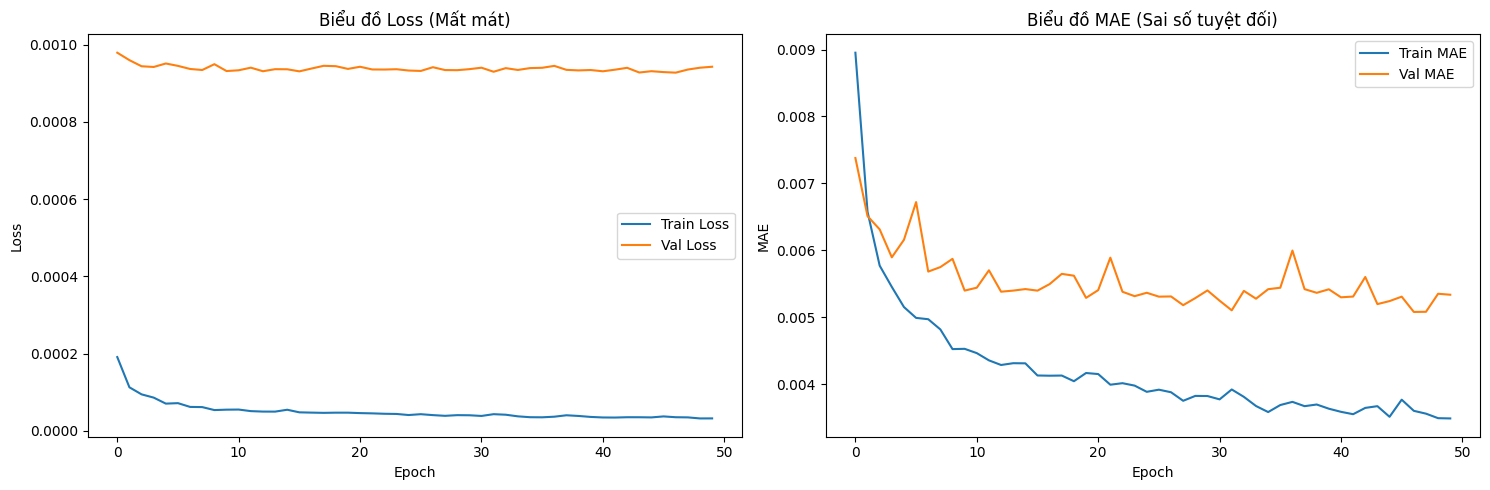

In [64]:
# Vẽ biểu đồ Loss và MAE (thay thế cho Accuracy vì đây là bài toán hồi quy)
plt.figure(figsize=(15, 5))

# Biểu đồ Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Biểu đồ Loss (Mất mát)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# Biểu đồ MAE
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.title('Biểu đồ MAE (Sai số tuyệt đối)')
plt.xlabel('Epoch')
plt.ylabel('MAE')
plt.legend()

plt.tight_layout()
plt.show()

101/101 ━━━━━━━━━━━━━━━━━━━━ 0s 937us/step


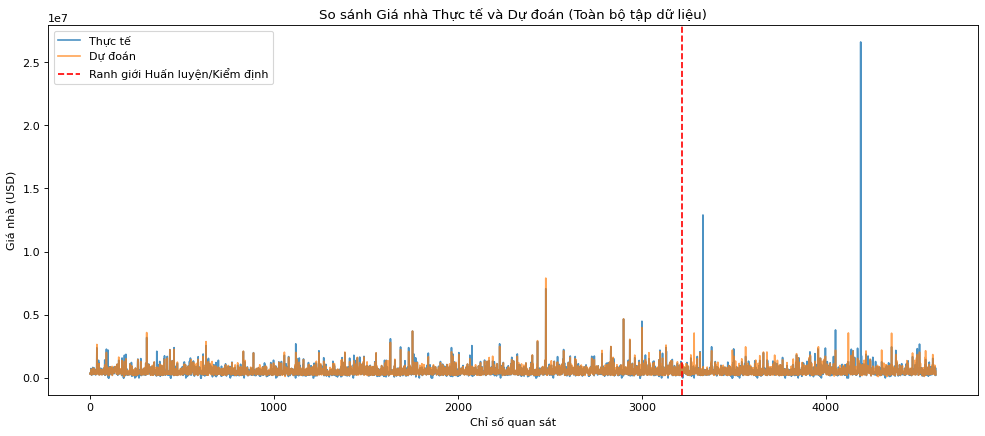

In [65]:
def plot_result(trainY, testY, train_predict, test_predict):
    # Chuyển đổi về thang đo gốc nếu cần (ở đây đã thực hiện trước khi gọi hàm)
    actual = np.append(trainY, testY)
    predictions = np.append(train_predict, test_predict)
    rows = len(actual)

    plt.figure(figsize=(15, 6), dpi=80)
    plt.plot(range(rows), actual, label='Thực tế', alpha=0.8)
    plt.plot(range(rows), predictions, label='Dự đoán', alpha=0.7)
    plt.axvline(x=len(trainY), color='r', linestyle='--', label='Ranh giới Huấn luyện/Kiểm định')

    plt.legend()
    plt.xlabel('Chỉ số quan sát')
    plt.ylabel('Giá nhà (USD)')
    plt.title('So sánh Giá nhà Thực tế và Dự đoán (Toàn bộ tập dữ liệu)')
    plt.show()

# Chuẩn bị dữ liệu dự đoán trên tập huấn luyện để vẽ biểu đồ tổng thể
y_train_pred_scaled = model.predict(X_train_rnn)
y_train_pred = scaler_y.inverse_transform(y_train_pred_scaled)
y_train_true = scaler_y.inverse_transform(y_train)

# Gọi hàm vẽ biểu đồ
plot_result(y_train_true, y_true, y_train_pred, y_pred)

In [67]:
# 5. Đánh giá và Lập bảng kết quả cập nhật
y_pred_scaled = model.predict(X_val_rnn)
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_true = scaler_y.inverse_transform(y_val)

r2 = r2_score(y_true, y_pred)
mae_val = np.mean(np.abs(y_true - y_pred))

def classify(r2_score):
    if r2_score > 0.8: return "Tốt"
    if r2_score > 0.5: return "Khá"
    if r2_score > 0.1: return "Trung bình"
    return "Tệ"

eval_table = pd.DataFrame({
    'Tiêu chí': ['Độ phù hợp (R-squared)', 'Sai lệch trung bình', 'Xếp loại chất lượng'],
    'Kết quả': [f"{r2*100:.2f}%", f"{mae_val:,.2f} USD", classify(r2)]
})

display(eval_table)

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


,Tiêu chí,Kết quả
0,Độ phù hợp (R-squared),7.81%
1,Sai lệch trung bình,"148,655.03 USD"
2,Xếp loại chất lượng,Tệ
